In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
sys.path.append("/n/home12/binxuwang/Github/NHP_NSD_analysis")
import numpy as np
import pandas as pd
from os.path import join
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from scipy import ndimage
import matplotlib.pyplot as plt
import numpy as np
from NSD_utils.h5_dataset_utils import load_data_from_GoodUnitStrc, explore_h5_structure
from NSD_utils.image_utils import pil_images_to_grid
from easydict import EasyDict as edict

In [20]:
NSD_root = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/Datasets/NSD_N3"
h5_file = h5py.File(join(NSD_root, "GoodUnit_240709_JianJian_NSD1000_LOC_g2.mat"), "r")
neural_data = load_data_from_GoodUnitStrc(h5_file)
neural_data = edict(neural_data)

trial_valid_idx (4460, 1)
dataset_valid_idx (4460, 1)
Raster (675, 450, 4308)
response_matrix_img (675, 450, 1072)
unittype (675,)
KSidx (675,)
spikepos (675, 2)
PsthRange (450,)


In [15]:
PsthRange = h5_file["global_params"]["PsthRange"][:].squeeze()
pre_offset = PsthRange[0] - 1
post_offset = PsthRange[-1] 

### Visualize

In [ ]:
kernel_size = 15
sigma = 5
x = np.arange(kernel_size) - (kernel_size - 1) / 2
gauss_kernel = np.exp(-x**2 / (2 * sigma**2))
gauss_kernel = gauss_kernel / gauss_kernel.sum()  # Normalize


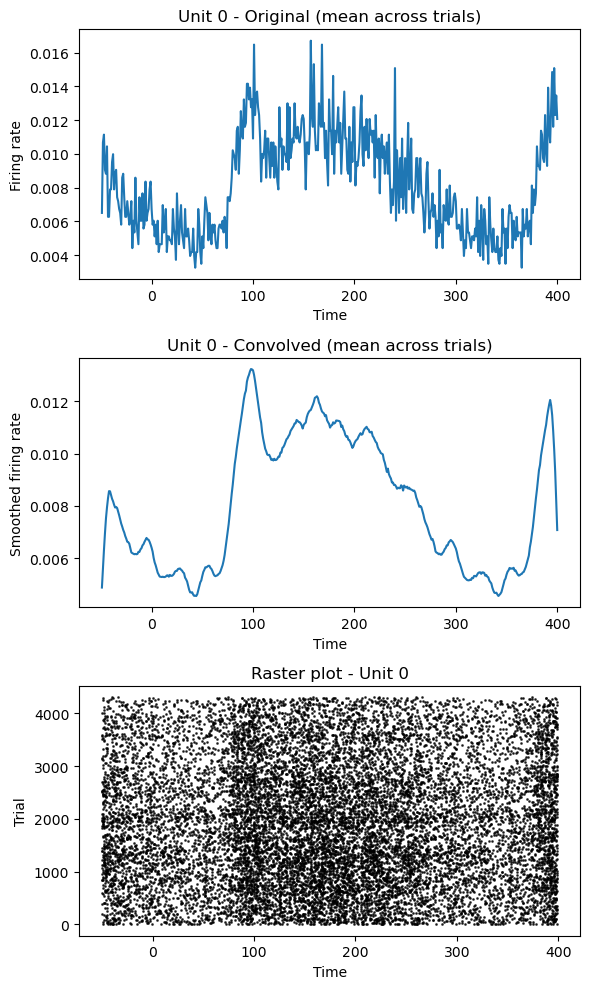

In [18]:
unit_idx = 0
raster_0 = neural_data.Raster[unit_idx,:,:]
raster_0_convolved = ndimage.convolve1d(raster_0.astype(np.float32), gauss_kernel, axis=0, mode='constant')
# Plot comparison
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 10))
# Original
ax1.plot(PsthRange, raster_0.astype(np.float32).mean(axis=1))
ax1.set_title(f"Unit {unit_idx} - Original (mean across trials)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Firing rate")
# Convolved
ax2.plot(PsthRange, raster_0_convolved.mean(axis=1))
ax2.set_title(f"Unit {unit_idx} - Convolved (mean across trials)")
ax2.set_xlabel("Time")
ax2.set_ylabel("Smoothed firing rate")
# Raster plot
trial_indices, time_indices = np.where(raster_0.T > 0)
ax3.scatter(time_indices + pre_offset, trial_indices, s=1, c='black', alpha=0.7)
ax3.set_xlabel('Time')
ax3.set_ylabel('Trial')
ax3.set_title(f'Raster plot - Unit {unit_idx}')
plt.tight_layout()
plt.show()

### Build tensor

In [41]:
valid_trial_stim_idx = neural_data.trial_valid_idx[neural_data.dataset_valid_idx[:, 0], 0]

In [42]:
valid_trial_stim_idx

array([808, 941, 148, ..., 318,  23, 699])

In [43]:
valid_trial_stim_idx.shape

(4308,)

In [44]:
neural_data.Raster.shape

(675, 450, 4308)

In [45]:
valid_trial_stim_idx

array([808, 941, 148, ..., 318,  23, 699])

In [46]:
img_idxs, img_counts = np.unique(valid_trial_stim_idx, return_counts=True)
max_repeats = img_counts.max()
img_idxs_max_repeats = img_idxs[img_counts == max_repeats]
img_counts_max_repeats = img_counts[img_counts == max_repeats]

In [47]:
img_idxs

array([   1,    2,    3, ..., 1070, 1071, 1072])

In [48]:
img_counts


array([4, 4, 4, ..., 4, 4, 4])

In [50]:
max_repeats

5

In [ ]:
img_idxs, img_repeat_counts = np.unique(valid_trial_stim_idx, return_counts=True)
max_repeats = img_repeat_counts.max()
img_psth_pad_tsr = []
for img_idx in range(1, neural_data.n_images+1):
    img_psth = neural_data.Raster[:,:, valid_trial_stim_idx == img_idx] #.astype(np.float32).mean(axis=-1)
    img_psth_pad = np.pad(img_psth, ((0, 0), (0, 0), (0, max_repeats - img_psth.shape[-1])), mode='constant', constant_values=0)
    img_psth_pad_tsr.append(img_psth_pad)
img_psth_pad_tsr = np.stack(img_psth_pad_tsr, axis=0)
img_psth_pad_tsr.shape

(1072, 675, 450, 5)

In [56]:
np.isnan(img_psth_pad_tsr).sum()

0

In [59]:
evk_slice = slice(100, 250)
bsl_slice = slice(0, 90)
evk_resp_tsr = neural_data.Raster[:, evk_slice, :].astype(np.float32).mean(axis=1) * 1000 # (n_units, n_trials)
bsl_resp_tsr = neural_data.Raster[:, bsl_slice, :].astype(np.float32).mean(axis=1) * 1000 # (n_units, n_trials)
evk_resp_img_pad_tsr = []
bsl_resp_img_pad_tsr = []
for img_idx in range(1, neural_data.n_images+1):
    n_repeat = np.sum(valid_trial_stim_idx == img_idx)
    evk_resp_img = evk_resp_tsr[:, valid_trial_stim_idx == img_idx] #.astype(np.float32).mean(axis=-1)
    bsl_resp_img = bsl_resp_tsr[:, valid_trial_stim_idx == img_idx] #.astype(np.float32).mean(axis=-1)
    evk_resp_img_pad = np.pad(evk_resp_img, ((0, 0), (0, max_repeats - n_repeat)), mode='constant', constant_values=np.nan)
    bsl_resp_img_pad = np.pad(bsl_resp_img, ((0, 0), (0, max_repeats - n_repeat)), mode='constant', constant_values=np.nan)
    evk_resp_img_pad_tsr.append(evk_resp_img_pad)
    bsl_resp_img_pad_tsr.append(bsl_resp_img_pad)
evk_resp_img_pad_tsr = np.stack(evk_resp_img_pad_tsr, axis=0)
bsl_resp_img_pad_tsr = np.stack(bsl_resp_img_pad_tsr, axis=0)
print(evk_resp_img_pad_tsr.shape)
print(bsl_resp_img_pad_tsr.shape)

(1072, 675, 5)
(1072, 675, 5)


In [61]:
np.nanmean(bsl_resp_img_pad_tsr, axis=-1)

array([[ 2.777778,  0.      ,  0.      , ...,  0.      ,  0.      ,
         5.555556],
       [ 5.555556,  0.      ,  0.      , ...,  5.555556,  2.777778,
        11.111112],
       [ 5.555556,  0.      ,  0.      , ...,  2.777778,  5.555556,
        11.111112],
       ...,
       [11.111112,  0.      ,  2.777778, ...,  0.      , 13.888889,
        11.111112],
       [13.888889,  0.      ,  2.777778, ...,  8.333334,  8.333334,
        16.666668],
       [ 8.333334,  0.      ,  0.      , ...,  0.      ,  0.      ,
         5.555556]], dtype=float32)

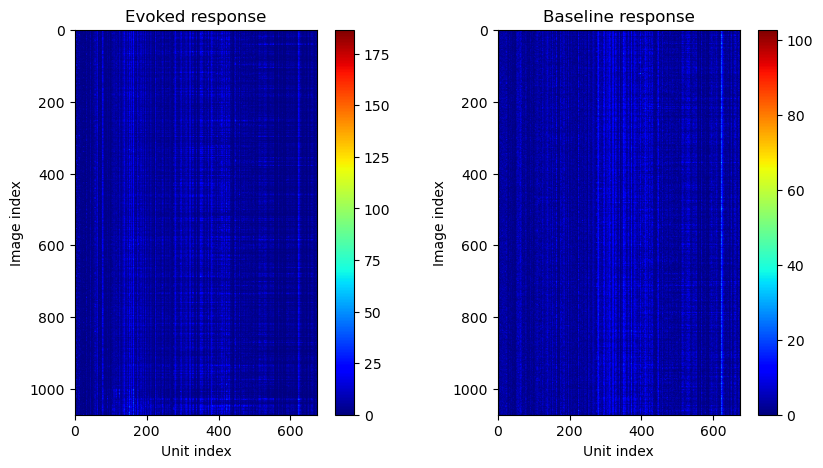

In [66]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.nanmean(evk_resp_img_pad_tsr, axis=-1), cmap='jet')
plt.ylabel("Image index")
plt.xlabel("Unit index")
plt.colorbar()
plt.title("Evoked response")
plt.subplot(1, 2, 2)
plt.imshow(np.nanmean(bsl_resp_img_pad_tsr, axis=-1), cmap='jet')
plt.ylabel("Image index")
plt.xlabel("Unit index")
plt.colorbar()
plt.title("Baseline response")
plt.show()

In [67]:
resp_mat = np.nanmean(evk_resp_img_pad_tsr, axis=-1) - np.nanmean(bsl_resp_img_pad_tsr, axis=-1)

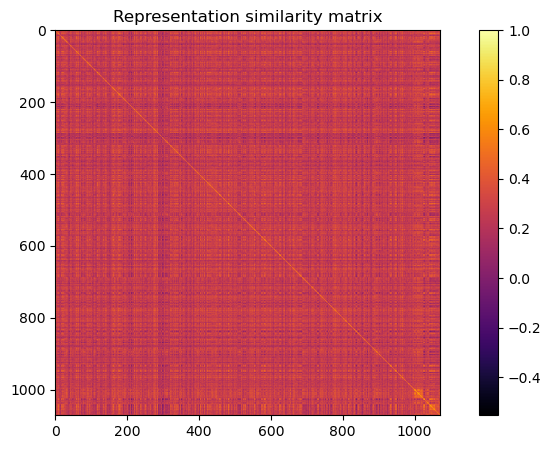

In [69]:
from sklearn.metrics.pairwise import cosine_similarity

repr_sim_mat = cosine_similarity(resp_mat, resp_mat)

plt.figure(figsize=(10, 5))
plt.imshow(repr_sim_mat, cmap='inferno')
plt.colorbar()
plt.title("Representation similarity matrix")
plt.show()

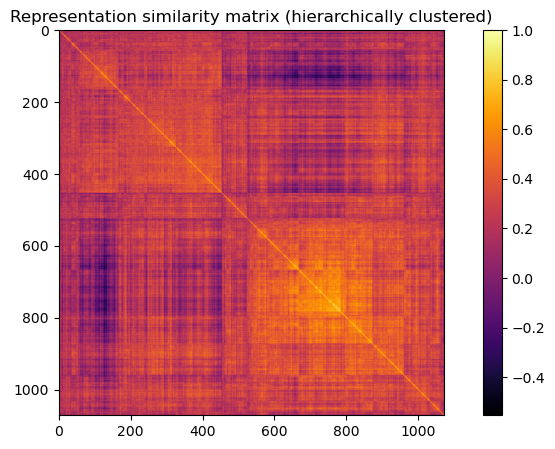

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

repr_sim_mat = cosine_similarity(resp_mat, resp_mat)

# Convert similarity to distance for clustering
distance_mat = 1 - repr_sim_mat
# Convert to condensed distance matrix for linkage
condensed_dist = squareform(distance_mat, checks=False)
# Perform hierarchical clustering
linkage_mat = linkage(condensed_dist, method='average')
# Get dendrogram to extract order
dendro = dendrogram(linkage_mat, no_plot=True)
order = dendro['leaves']

# Reorder the similarity matrix
repr_sim_mat_sorted = repr_sim_mat[order][:, order]

plt.figure(figsize=(10, 5))
plt.imshow(repr_sim_mat_sorted, cmap='inferno')
plt.colorbar()
plt.title("Representation similarity matrix (hierarchically clustered)")
plt.show()

### Loading images and view clusters

In [75]:
stimdir = join(NSD_root, "NSD1000_LOC")

In [85]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms

vis_transform = None
# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset using ImageFolder
nsd_dataset = ImageFolder(root=NSD_root, transform=None)
print(f"Dataset size: {len(nsd_dataset)}")
print(f"Classes: {nsd_dataset.classes}")

# Create dataloader
dataloader = DataLoader(nsd_dataset, batch_size=32, shuffle=False)

Dataset size: 1072
Classes: ['NSD1000_LOC']


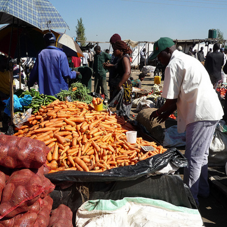

In [83]:
nsd_dataset[0][0]

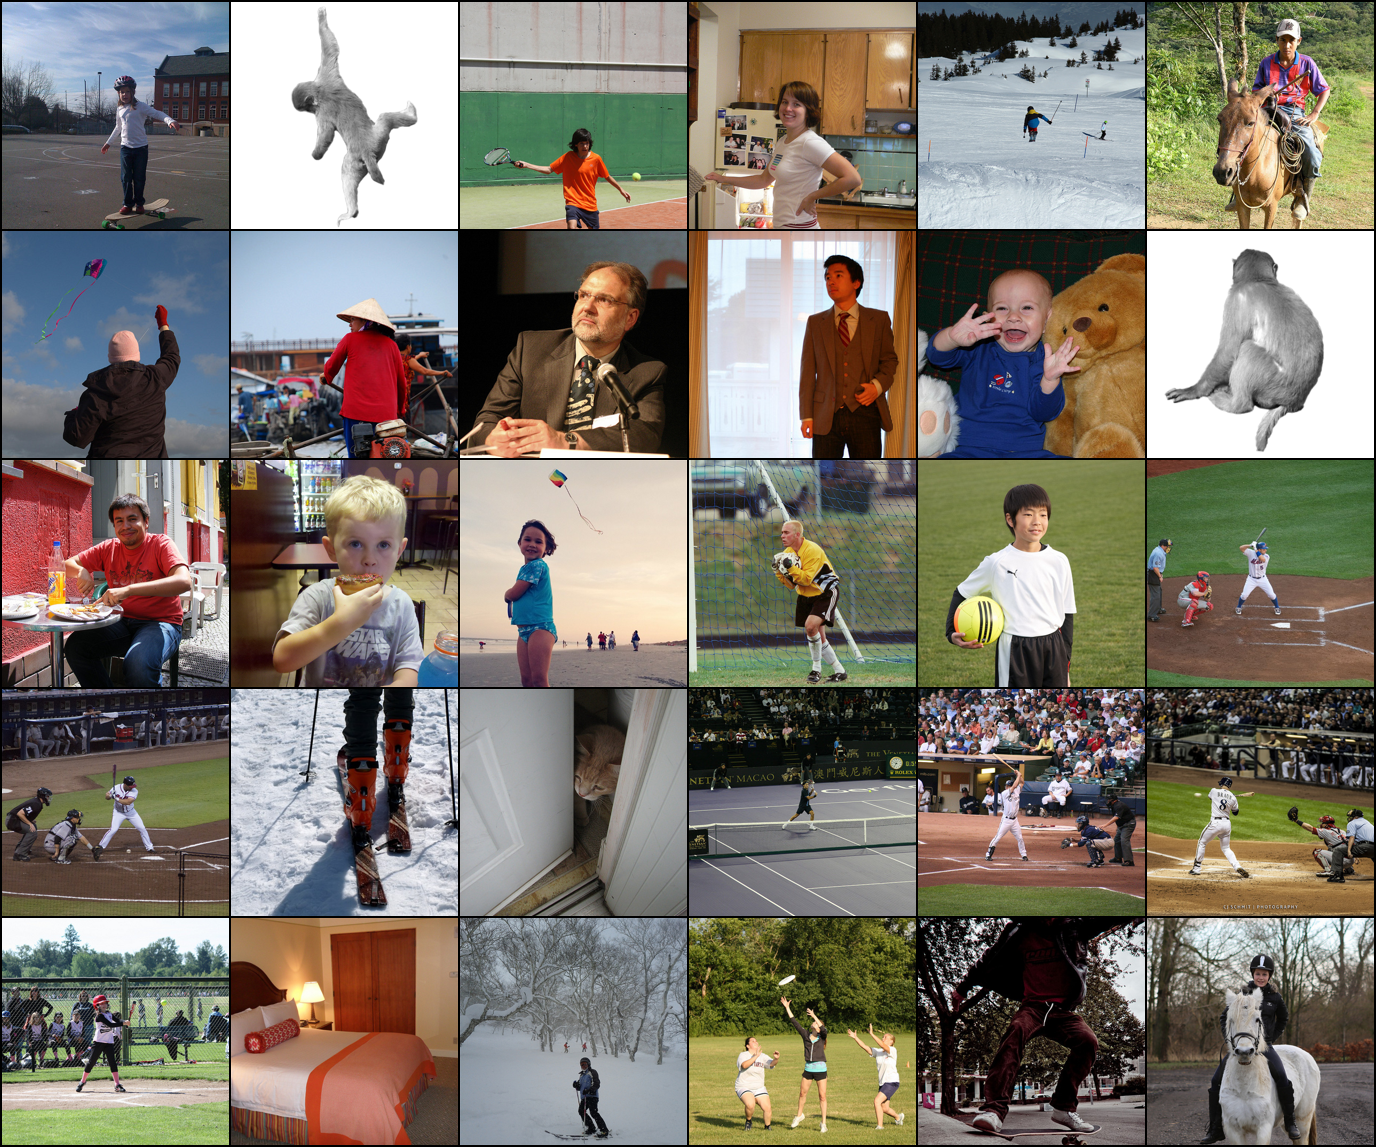

In [91]:
sorted_imgs = [nsd_dataset[img_idx][0] for img_idx in order[650:680]]
pil_images_to_grid(sorted_imgs, )

In [102]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import fcluster

repr_sim_mat = cosine_similarity(resp_mat, resp_mat)

# Convert similarity to distance for clustering
distance_mat = 1 - repr_sim_mat
# Convert to condensed distance matrix for linkage
condensed_dist = squareform(distance_mat, checks=False)
# Perform hierarchical clustering
linkage_mat = linkage(condensed_dist, method='average')
# Get dendrogram to extract order
dendro = dendrogram(linkage_mat, no_plot=True)
order = dendro['leaves']

n_clusters = 20
cluster_labels = fcluster(linkage_mat, n_clusters, criterion='maxclust')
print(f"Cluster labels shape: {cluster_labels.shape}")
print(f"Number of unique clusters: {len(np.unique(cluster_labels))}")
print(f"Cluster distribution: {np.bincount(cluster_labels)}")

Cluster labels shape: (1072,)
Number of unique clusters: 20
Cluster distribution: [  0   1   1   2   2   2   3   2   6   5   7   3  13   5 401   4   9 595
   1   4   6]


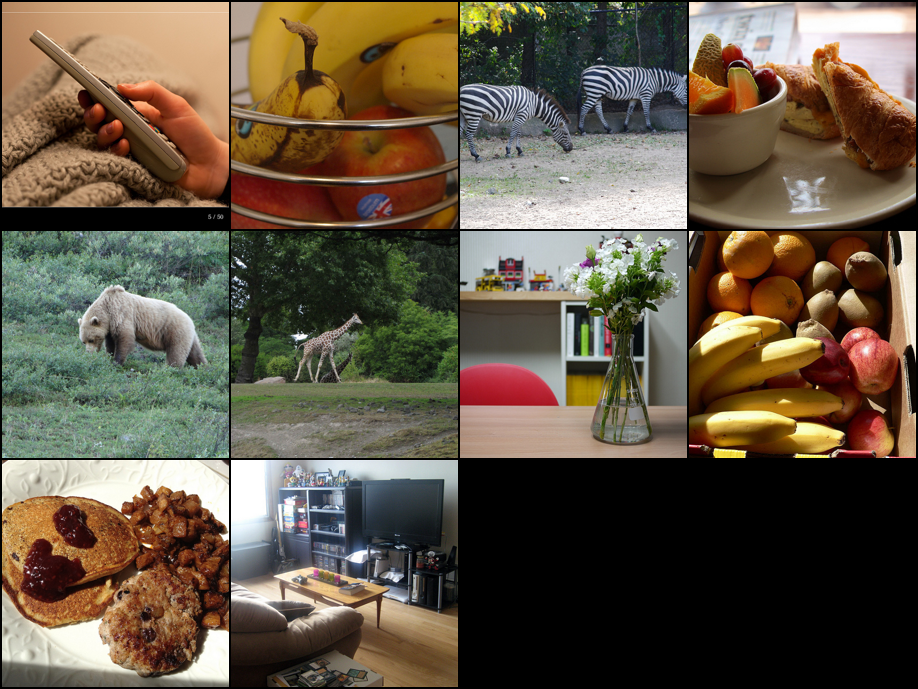

In [104]:
sorted_imgs = [nsd_dataset[img_idx][0] for img_idx in np.where(cluster_labels==12)[0][:10]]
pil_images_to_grid(sorted_imgs, )

### unzip the dataset

In [ ]:
!ls {NSD_root}

drive-download-20250715T201056Z-1-001.zip
drive-download-20250715T201056Z-1-002.zip
drive-download-20250715T201056Z-1-003.zip
drive-download-20250715T201056Z-1-004.zip
drive-download-20250715T201056Z-1-005.zip
drive-download-20250715T201056Z-1-006.zip
drive-download-20250715T201056Z-1-007.zip
drive-download-20250715T201056Z-1-008.zip
drive-download-20250715T201056Z-1-009.zip
drive-download-20250715T201056Z-1-010.zip
GoodUnit_240629_JianJian_NSD1000_LOC_g2.mat
GoodUnit_240708_JianJian_NSD1000_LOC_g2.mat
GoodUnit_240709_JianJian_NSD1000_LOC_g2.mat
GoodUnit_240711_FaCai_NSD1000_LOC_g4.mat
GoodUnit_240719_FaCai_NSD1000_LOC_g3.mat
GoodUnit_240720_FaCai_NSD1000_LOC_g2.mat
GoodUnit_240722_FaCai_NSD1000_LOC_g0.mat
GoodUnit_240724_TuTu_NSD1000_LOC_g2.mat
GoodUnit_240725_FaCai_NSD1000_LOC_g1.mat
GoodUnit_240726_TuTu_NSD1000_LOC_g3.mat
GoodUnit_240728_JianJian_NSD1000_LOC_g3.mat
GoodUnit_240730_JianJian_NSD1000_LOC_g2.mat
GoodUnit_240801_JianJian_NSD1000_LOC_g1.mat
GoodUnit_240807_FaCai_NSD1000_L

In [ ]:
!unzip {NSD_root}/NSD1000_LOC.zip -d {NSD_root}/

In [74]:
!mkdir {NSD_root}/NSD1000_LOC
!mv {NSD_root}/*.bmp {NSD_root}/NSD1000_LOC/
!mv {NSD_root}/*.tsv {NSD_root}/NSD1000_LOC/

mkdir: cannot create directory ‘/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/Datasets/NSD_N3/NSD1000_LOC’: File exists
